In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df  = pd.read_excel(r'C:\Users\ACER\Desktop\maas.xlsx')
df

,Ad,Maas
0,Təcrübəçi 1,400
1,Təcrübəçi 2,450
2,İşçi 1,800
3,İşçi 2,850
4,İşçi 3,900
5,İşçi 4,900
6,İşçi 5,950
7,İşçi 6,1000
8,İşçi 7,1100
9,İşçi 8,1150


In [18]:
# 2. Kvartilləri hesablayaq
# describe() bizə bütün statistikani verir
statistika = df['Maas'].describe()
statistika

count      18.00000
mean     1275.00000
std       980.58356
min       400.00000
25%       900.00000
50%      1125.00000
75%      1337.50000
max      5000.00000
Name: Maas, dtype: float64

In [23]:
# Tək-tək çıxarmaq istəsək:
q1 = df['Maas'].quantile(0.25)
q2 = df['Maas'].median()  # Və ya quantile(0.50)
q3 = df['Maas'].quantile(0.75)
iqr = q3-q1
print(q1)
print(q2)
print(q3)
print("iqr:",iqr)

900.0
1125.0
1337.5
iqr: 437.5


In [22]:
# 3. Outlier Sərhədlərini Təyin edək (Qızıl Qayda)
lower_bound = q1 - 1.5 * iqr   # Aşağı sərhəd
upper_bound = q3 + 1.5 * iqr   # Yuxarı sərhəd

# 4. Outlier-ləri (Sərhədi aşanları) tapaq
# Şərt: Aşağı sərhəddən kiçik VƏ YA (|) Yuxarı sərhəddən böyük
outliers = df[(df["Maas"] < lower_bound) | (df["Maas"] > upper_bound)]

outliers


,Ad,Maas
17,CEO,5000


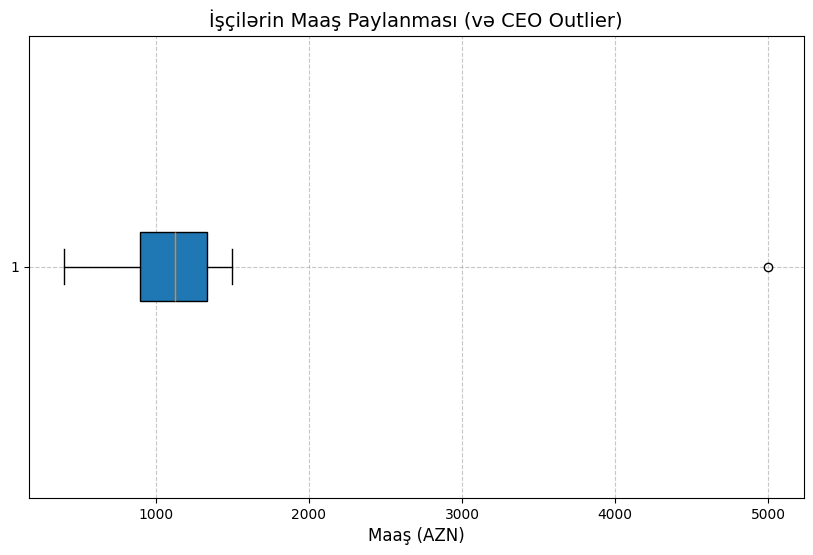

In [25]:

# 1. Şəklin ölçüsünü təyin edirik (Eni 10, Hündürlüyü 6)
plt.figure(figsize=(10, 6))

# 2. Boxplot-u qururuq
# df['Maas'] -> Sizin datanızdakı maaş sütunu
# vert=False -> Qrafiki üfüqi (yatıq) edir (baxmaq daha rahatdır)
# patch_artist=True -> Qutunun içini rəngləyir
plt.boxplot(df['Maas'], vert=False, patch_artist=True)

# 3. Başlıq və Etiketlər (Qrafik anlaşıqlı olsun deyə)
plt.title('İşçilərin Maaş Paylanması (və CEO Outlier)', fontsize=14)
plt.xlabel('Maaş (AZN)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7) # Arxa fona tor (setka) əlavə edirik

# 4. Şəkli göstəririk
plt.show()

In [11]:
# 1. Datanı yaradaq (Bayaqkı çətin imtahan nümunəsi)
# Hamı 10-12 alıb, bir nəfər (Siz) 15 almısınız.
data = {
    'Telebe': ['Ali', 'Veli', 'Hesen', 'Arzu', 'Siz', 'Zaur'],
    'Bal': [10, 12, 10, 11, 15, 10]
}

df = pd.DataFrame(data)

# --- ÜSUL 1: Pandas ilə (Düsturu özümüz yazırıq) ---
# Düstur: (X - Mean) / StDev
mean_val = df['Bal'].mean()
std_val = df['Bal'].std()

df['Z_Score_Manual'] = (df['Bal'] - mean_val) / std_val
df

,Telebe,Bal,Z_Score_Manual
0,Ali,10,-0.678064
1,Veli,12,0.339032
2,Hesen,10,-0.678064
3,Arzu,11,-0.169516
4,Siz,15,1.864675
5,Zaur,10,-0.678064
